In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import expm_multiply

import sys
from os.path import join
sys.path.append(join(".", ".."))
from utils import *
from lchs_utils import *
from schrodingerization_utils import *

from qiskit import transpile
from qiskit_aer import Aer

Schrodingerization

In [2]:
'''Modifiable parameters'''
n_p = 7                         # Number of qubits for p
n_x = 3                         # Number of qubits for x
n = n_x + n_p
R = 25                           # Right boundary endpoint
T = 0.5#5                        # Evolution time
N_t = 5#10                        # Number of time points

J = 1
h = 1
gamma_x = 0
gamma_z = 0.1
trotter_method = "second_order"
qft_approx_degree = 0

K = R
M = 128

N_p = 2 ** n_p
h_p = (2 * R) / (N_p - 1)
p = np.linspace(-R, R, N_p)
print("N_p:", N_p)
print(f"Total number of qubits: {n_p + n_x}")
t_vals = np.linspace(0, T, N_t)
r_vals = np.ceil(t_vals ** 2)
print(r_vals)

H_1 = - gamma_z * sum_delta_n(n_x, delta=2 * np.ones(n_x))
H_2 = - (h * sum_x(n_x) + J * sum_J_zz(n_x, diags([np.ones(n_x-1)], [1]).toarray()))

A = H_1 + 1j * H_2

print("H1:", H_1.toarray())
print("H2:", H_2.toarray())
print(f"Norm of H1: {np.linalg.norm(H_1.toarray(), ord=2):0.3f}")
print(f"Norm of H2: {np.linalg.norm(H_2.toarray(), ord=2):0.3f}")

N_p: 128
Total number of qubits: 10
[0. 1. 1. 1. 1.]
H1: [[ 0.   0.   0.   0.   0.   0.   0.   0. ]
 [ 0.  -0.2  0.   0.   0.   0.   0.   0. ]
 [ 0.   0.  -0.2  0.   0.   0.   0.   0. ]
 [ 0.   0.   0.  -0.4  0.   0.   0.   0. ]
 [ 0.   0.   0.   0.  -0.2  0.   0.   0. ]
 [ 0.   0.   0.   0.   0.  -0.4  0.   0. ]
 [ 0.   0.   0.   0.   0.   0.  -0.4  0. ]
 [ 0.   0.   0.   0.   0.   0.   0.  -0.6]]
H2: [[-2. -1. -1.  0. -1.  0.  0.  0.]
 [-1.  0.  0. -1.  0. -1.  0.  0.]
 [-1.  0.  2. -1.  0.  0. -1.  0.]
 [ 0. -1. -1.  0.  0.  0.  0. -1.]
 [-1.  0.  0.  0.  0. -1. -1.  0.]
 [ 0. -1.  0.  0. -1.  2.  0. -1.]
 [ 0.  0. -1.  0. -1.  0.  0. -1.]
 [ 0.  0.  0. -1.  0. -1. -1. -2.]]
Norm of H1: 0.600
Norm of H2: 3.494


In [3]:
hamming_weight_operator = np.zeros(2 ** n_x)
for i in range(2 ** n_x):
    hamming_weight_operator[i] = i.bit_count()

In [4]:
H = h * sum_x(n_x) + J * sum_J_zz(n_x, diags([np.ones(n_x-1)], [1]).toarray()) \
      - 1j * (gamma_z * sum_delta_n(n_x, delta=2 * np.ones(n_x)))

psi_0 = np.zeros(2 ** n_x)
psi_0[0] = 1
# psi_0 = np.ones(2 ** n)
# psi_0 /= np.linalg.norm(psi_0)
psi = expm_multiply(-1j * H * T, psi_0)

obs_gt = np.real(np.conj(psi) @ (hamming_weight_operator * psi))# / np.linalg.norm(psi[i]) ** 2


In [5]:
num_shots_schro_vals = np.array([100, 1000, 10000, 100000])

obs_schro = np.zeros(len(num_shots_schro_vals))
obs_sq_schro = np.zeros(len(num_shots_schro_vals))
obs_lchs = np.zeros(len(num_shots_schro_vals))
var_lchs = np.zeros(len(num_shots_schro_vals))

t = T
print(f"Running t ={t : 0.2f}")
r = 20

np.random.seed(0)

for i, num_shots_schro in enumerate(num_shots_schro_vals):
    
    print(f"Total number of shots = {num_shots_schro}")
    # Schrodingerization
    # Simulate with sampling
    circuit = get_full_circuit(n_x, n_p, t, H_1, H_2, r, R, trotter_method=trotter_method, qft_approx_degree=qft_approx_degree)
    circuit.measure_all()
    compiled_circuit = transpile(circuit, basis_gates=['rx', 'ry', 'rz', 'rxx', 'swap'], optimization_level=3)
    print("Schrodingerization:", compiled_circuit.depth())
    # print(compiled_circuit.count_ops())

    # Run the quantum circuit on a statevector simulator backend
    backend = Aer.get_backend('statevector_simulator')
    job = backend.run(compiled_circuit, shots=num_shots_schro)
    # job = backend.run(compiled_circuit)
    result = job.result()
    
    counts = result.get_counts(compiled_circuit)
    # print(result)
    dist_sim = np.zeros(2 ** n)
    obs_vals = []
    for key in counts.keys():
        bitstring = np.zeros(n, dtype=int)
        for j in range(n):
            bitstring[j] = int(key[n-1-j])
        dist_sim[bitstring_to_int(bitstring)] = counts[key] / num_shots_schro
    # plt.plot(dist_sim, label="sim")
    

    # a = 0
    # assert 0 <= a < R, "a is not within [0,R], increase R"
    a_idx = N_p // 2# + int(a / h)
    # u_recover[i] = np.exp(a) * np.sum(np.reshape(v, newshape=(N_t, dimension, N))[i,:,a_idx:], axis=1) * h
    freq_reshaped = np.reshape(dist_sim, newshape=(2 ** n_x, N_p))[:,a_idx:]
    obs_schro[i] = 2 * np.sum(freq_reshaped.T @ hamming_weight_operator)
    obs_sq_schro[i] = np.sum(freq_reshaped.T @ ((2 * hamming_weight_operator) ** 2))

    num_samples_lchs = 100
    num_shots_lchs = num_shots_schro / num_samples_lchs
    obs_lchs[i], var_lchs[i] = run_lchs(n_x, t, J, h, gamma_x, gamma_z, r, K, M, num_samples_lchs, num_shots_lchs)

    
    print("Finished.")

# (Biased) sample variance
std_error_schro = np.sqrt((obs_sq_schro - obs_schro ** 2) / num_shots_schro_vals)
std_error_lchs = np.sqrt(var_lchs / num_shots_schro_vals)

Running t = 0.50
Total number of shots = 100
Schrodingerization: 500
max LCHS depth: 164
Finished.
Total number of shots = 1000
Schrodingerization: 500
max LCHS depth: 164
Finished.
Total number of shots = 10000
Schrodingerization: 500
max LCHS depth: 164
Finished.
Total number of shots = 100000
Schrodingerization: 500
max LCHS depth: 164
Finished.


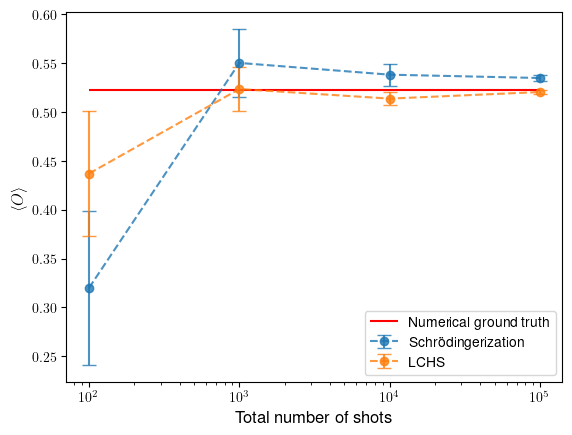

In [6]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": "Helvetica",
})

# plt.plot(t_vals, obs_gt, '-o', label="Ground truth")
plt.errorbar(num_shots_schro_vals, 
             obs_schro, 
             yerr=std_error_schro, 
             fmt='--o', 
             label="Schrödingerization",
             alpha=0.8,
             capsize=5)
plt.errorbar(num_shots_schro_vals, 
             obs_lchs, 
             yerr=std_error_lchs, 
             fmt='--o', 
             label="LCHS",
             alpha=0.8,
             capsize=5)
plt.hlines(y=obs_gt, 
           xmin=num_shots_schro_vals[0], 
           xmax=num_shots_schro_vals[-1], 
           label="Numerical ground truth", color="red")
plt.ylabel(rf"$\langle O \rangle$", fontsize=12)
plt.xlabel(rf"Total number of shots", fontsize=12)
plt.xscale('log')
plt.legend()
plt.savefig("../../figures/lchs_schro_comparison.pdf")
plt.show()